## Análise de Dados com Pandas

## Parte 1: Introdução e Carregamento de Dados (Alunos)

### Carregando Base de Dados de Alunos

In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/desafios/alunos.csv'
alunos = pd.read_csv(url)
display(alunos.head())

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,NaN,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True


### Visão Geral Inicial: Primeiras e Últimas Linhas

In [ ]:
alunos.head(7)

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,NaN,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True
5,Bruna,23,NaN,False
6,Dara,21,7.0,True


In [ ]:
alunos.tail(5)

,Nome,Idade,Notas,Aprovado
13,Mirla,25,9.0,True
14,Paulo,37,NaN,False
15,Mylena,29,7.0,True
16,Lucas,33,NaN,False
17,Nadia,34,8.0,True


### Verificando as Dimensões do DataFrame

In [ ]:
print(f"A tabela possui {alunos.shape[0]} linhas e {alunos.shape[1]} colunas.")

A tabela possui 18 linhas e 4 colunas.


### Explorando Tipos de Dados e Informações Gerais

In [ ]:
alunos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Nome      18 non-null     object 
 1   Idade     18 non-null     int64  
 2   Notas     12 non-null     float64
 3   Aprovado  18 non-null     bool   
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 582.0+ bytes


### Estatísticas Descritivas Básicas

In [ ]:
alunos.describe()

,Idade,Notas
count,18.000000,12.000000
mean,25.500000,6.800000
std,6.070662,2.204953
min,18.000000,2.500000
25%,21.000000,5.450000
50%,24.500000,7.000000
75%,28.750000,8.250000
max,37.000000,10.000000


## Parte 2: Análise Exploratória de Dados (Imóveis)

### Preparação e Filtragem Inicial dos Dados de Imóveis

In [ ]:
# O pandas já foi importado no início do notebook (célula vGH2QKP6JL-f), esta linha é redundante.

In [ ]:
# Importando a base de dados de imóveis
url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'
dados = pd.read_csv(url, sep=';')
display(dados.head())

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [ ]:
imoveis_comerciais = ['Conjunto Comercial/Sala',
                      'Prédio Inteiro', 'Loja/Salão',
                      'Galpão/Depósito/Armazém',
                      'Casa Comercial', 'Terreno Padrão',
                      'Loja Shopping/ Ct Comercial',
                      'Box/Garagem', 'Chácara',
                      'Loteamento/Condomínio', 'Sítio',
                      'Pousada/Chalé', 'Hotel', 'Indústria']

# removendo imóveis comerciais
df = dados.query('@imoveis_comerciais not in Tipo')

# selecionando apenas imóveis do tipo apartamento
df = df.query('Tipo == "Apartamento"')

# visualizando a base de dados filtrada
display(df.head())

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN


### Média de Quartos por Apartamento

In [ ]:
media_quartos_apt = df['Quartos'].mean().round()
print(f"{int(media_quartos_apt)} quartos é a média de quartos por apartamento.")

2 quartos é a média de quartos por apartamento.


### Contagem de Bairros Únicos

In [ ]:
quant_bairros_unicos = df['Bairro'].nunique()
print(f"Existem {quant_bairros_unicos} bairros únicos na base de dados de apartamentos.")

Existem 149 bairros únicos na base de dados de apartamentos.


### Bairros com os Maiores Valores Médios de Aluguel

In [ ]:
df_maiores_valores = df.groupby('Bairro')['Valor'].mean().sort_values(ascending=False).head(5).reset_index()
df_maiores_valores.rename(columns={'Valor': 'Media_Valor_Aluguel'}, inplace=True)
display(df_maiores_valores)

,Bairro,Media_Valor_Aluguel
0,Joá,15500.000000
1,Arpoador,12429.769231
2,Cidade Jardim,12000.000000
3,Ipanema,9487.205317
4,Botafogo,9369.207116


### Visualização: Top 5 Bairros com Maiores Aluguéis

<Figure size 1000x600 with 0 Axes>

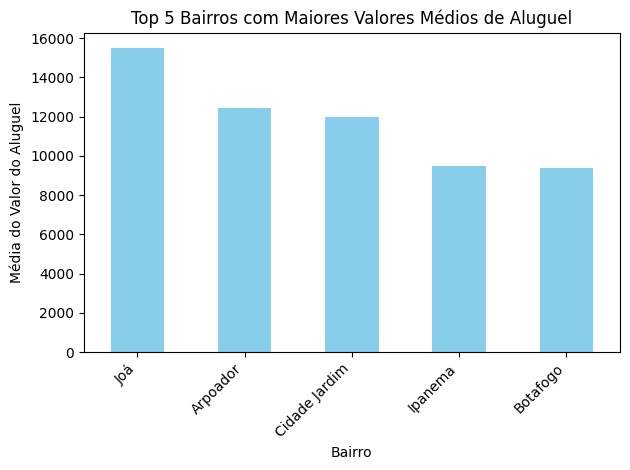

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_maiores_valores.plot(kind='bar', x='Bairro', y='Media_Valor_Aluguel', legend=False, color='skyblue')
plt.title('Top 5 Bairros com Maiores Valores Médios de Aluguel')
plt.xlabel('Bairro')
plt.ylabel('Média do Valor do Aluguel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Parte 3: Limpeza e Pré-processamento de Dados (Alunos)

In [ ]:
# Esta célula reimporta os dados de 'alunos', o que pode sobrescrever alterações feitas anteriormente.
# Para manter a consistência do DataFrame 'alunos' em todo o notebook, é melhor evitar reimportar
# se já foi carregado e tratado. A célula TRLTBVThxo1g já carrega e trata os NaNs.
# url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/desafios/alunos.csv'
# alunos = pd.read_csv(url)

### Identificação e Tratamento de Valores Nulos

In [ ]:
print("Valores nulos antes do tratamento:")
display(alunos.isnull().sum())

Valores nulos antes do tratamento:


,0
Nome,0
Idade,0
Notas,6
Aprovado,0


In [ ]:
alunos = alunos.fillna(0)
print("DataFrame após o tratamento de valores nulos (substituídos por 0):")
display(alunos.head())

DataFrame após o tratamento de valores nulos (substituídos por 0):


,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,0.0,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True


### Remoção de Alunos do DataFrame

In [ ]:
alunos = alunos.drop(alunos[alunos['Nome'].isin(['Alice', 'Carlos'])].index)
alunos

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,0.0,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True
5,Bruna,23,0.0,False
6,Dara,21,7.0,True
9,Vitor,28,0.0,False
10,Daniel,21,0.0,False
11,Igor,24,4.5,False


### Filtrando Apenas Alunos Aprovados

In [ ]:
aprovado = (alunos['Aprovado'] == True)
alunos[aprovado]

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
4,Beto,21,10.0,True
6,Dara,21,7.0,True
12,Sthefanie,26,9.5,True
13,Mirla,25,9.0,True
15,Mylena,29,7.0,True
17,Nadia,34,8.0,True


### Exportando Dados dos Alunos Aprovados

In [ ]:
alunos[aprovado].to_csv('alunos_aprovados.csv', index=False)

In [ ]:
al_apv = pd.read_csv('alunos_aprovados.csv')

### Correção de Notas: Adicionando Pontos Extras para Aprovados

In [ ]:
al_apv.replace(to_replace=7.0 , value=8.0, inplace=True)

## Parte 4: Análise de Impacto de Pontos Extras (Alunos)

In [ ]:
# Importando novamente os dados para esta seção
url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/desafios/alunos.csv'
alunos = pd.read_csv(url)

# Aplicando o tratamento de valores nulos logo após a importação para garantir cálculos consistentes
alunos.fillna(0, inplace=True)
display(alunos.head())

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,0.0,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True


### Calculando os Pontos Extras dos Alunos

In [ ]:
alunos['Pontos_Extras'] = alunos['Notas'] * 0.4
alunos['Pontos_Extras'].fillna(0, inplace=True) # Preenche NaNs resultantes de 'Notas' NaNs com 0
display(alunos.head())

/tmp/ipykernel_9483/3708476829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  alunos['Pontos_Extras'].fillna(0, inplace=True) # Preenche NaNs resultantes de 'Notas' NaNs com 0


,Nome,Idade,Notas,Aprovado,Pontos_Extras
0,Ary,20,7.5,True,3.0
1,Ana,18,0.0,False,0.0
2,Cátia,27,2.5,False,1.0
3,Denis,18,5.0,False,2.0
4,Beto,21,10.0,True,4.0


### Determinando Notas Finais com Pontos Extras

In [ ]:
soma = alunos['Notas'] + alunos['Pontos_Extras']
alunos['Notas_Finais'] = soma.apply(lambda x: 10.0 if x >= 10 else x)
display(alunos.head())

,Nome,Idade,Notas,Aprovado,Pontos_Extras,Notas_Finais
0,Ary,20,7.5,True,3.0,10.0
1,Ana,18,0.0,False,0.0,0.0
2,Cátia,27,2.5,False,1.0,3.5
3,Denis,18,5.0,False,2.0,7.0
4,Beto,21,10.0,True,4.0,10.0


### Atualizando Status de Aprovação Final

In [ ]:
alunos['Aprovado_Final'] = alunos['Notas_Finais'].apply(lambda x: True if x >= 6 else False)
display(alunos.head())

,Nome,Idade,Notas,Aprovado,Pontos_Extras,Notas_Finais,Aprovado_Final
0,Ary,20,7.5,True,3.0,10.0,True
1,Ana,18,0.0,False,0.0,0.0,False
2,Cátia,27,2.5,False,1.0,3.5,False
3,Denis,18,5.0,False,2.0,7.0,True
4,Beto,21,10.0,True,4.0,10.0,True


### Identificando Alunos com Mudança de Status de Aprovação

In [ ]:
alunos[(alunos['Aprovado'] == False) & (alunos['Aprovado_Final'] == True)]

,Nome,Idade,Notas,Aprovado,Pontos_Extras,Notas_Finais,Aprovado_Final
3,Denis,18,5.0,False,2.00,7.00,True
8,Alice,35,5.6,False,2.24,7.84,True
11,Igor,24,4.5,False,1.80,6.30,True
